In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/LangChain

/content/drive/MyDrive/Colab Notebooks/LangChain


In [3]:
# bitsandbytes : 양자화 라이브러리
# pyngrok : 터널링 도구
!pip install -qU ultralytics openai bitsandbytes streamlit pyngrok

# qwen_vl_utils : Qwen 모델에서 이미지·비디오 전처리 및 입력 변환을 돕는 유틸리티 모듈
# av : Python 바인딩을 제공하는 FFmpeg 래퍼 (비디오/오디오 파일 디코딩 & 인코딩,
#      프레임 단위 접근, 다양한 코덱(H.264, VP9 등) 지원, FFmpeg과 동일한 강력한 포맷 호환성)
!pip install -q qwen_vl_utils av

!pip install -q diffusers

!pip install -qU langchain>=1.0.0 langchain-community langchain-experimental langchain-text-splitters langchain_tavily
!pip install -qU langchain-openai langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 34.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.3 MB/s eta 0:00:00


In [4]:
import os

In [5]:
# OpenAI Key 환경변수 설정
with open("/content/drive/MyDrive/Colab Notebooks/LangChain/key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [6]:
# Google Key 환경변수 설정
with open("/content/drive/MyDrive/Colab Notebooks/LangChain/key/google_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['GOOGLE_API_KEY'] = api_key

In [7]:
import matplotlib.pyplot as plt
import cv2, base64, time, os, torch, io, json, re
from PIL import Image
import numpy as np
from tqdm import tqdm
import base64

from ultralytics import YOLO
from openai import OpenAI
# import google.generativeai as genai # 구버전 SDK
# 신버전 SDK
from google import genai
from google.genai import types

# AI 모델을 웹 데모로 손쉽게 만드는 라이브러리
import gradio as gr
from pyngrok import ngrok
from pathlib import Path

from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
# 양자화
from transformers import BitsAndBytesConfig

# 모델에 대한 비디오 데이터 준비
from qwen_vl_utils import process_vision_info
from diffusers import StableDiffusionPipeline
from diffusers import StableDiffusion3Pipeline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [8]:
# 라이브러리 import
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal, Any
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
# 노드 : 그래프에서의 작업 단위, 실제 작업을 수행하는 함수
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown

In [9]:
from langchain.tools import tool # 에이전트가 스스로 선택하는 도구
# 모델 연동
import openai
from langchain.chat_models import init_chat_model
from langchain_openai.embeddings import OpenAIEmbeddings

# 프롬프트
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 메모리 기능
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.messages import HumanMessage, AIMessage

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

/tmp/ipykernel_557/408515407.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chat_message_histories import ChatMessageHistory


# Stablediffusion 기반 이미지 생성

### 이미지 생성 예시

In [10]:
#checkpoint = "runwayml/stable-diffusion-v1-5"

# 모델 불러오기 (Stable Diffusion 모델)
#pipe = StableDiffusionPipeline.from_pretrained(
#    checkpoint, torch_dtype=torch.float16).to("cuda")

In [11]:
# 텍스트 프롬프트 기반 이미지 생성 (GPU환경에서 수행)
#prompt = "a fantasy castle at sunset, highly detailed, 4k"
#image = pipe(prompt).images[0]

#image

- Vision Function 정의

In [77]:
# 사용할 모델의 저장소 주소
SD_CHECKPOINT = "runwayml/stable-diffusion-v1-5"
pipe = None

def load_image_generation_pipeline(checkpoint : str) :
    ''' 이미지 생성모델을 로딩하는 함수 '''
    global pipe

    if pipe is not None :
        return pipe

    # 모델 불러오기 (Stable Diffusion 모델)
    pipe = StableDiffusionPipeline.from_pretrained(
        checkpoint, torch_dtype=torch.float16).to("cuda")

    return pipe

In [13]:
pipe = load_image_generation_pipeline(SD_CHECKPOINT)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [78]:
client_GPT = None

def setPrompt(user_prompt : str) :
    global client_GPT
    #OpenAI 호출 도구가 생성되지 않은 경우
    if client_GPT is None:
        client_GPT = OpenAI()

    system_prompt = f"""
        당신은 이미지 생성에 필요한 프롬프트를 작성하는 전문가이다.
        {user_prompt}는 이미지 생성을 위해 사용할 프롬프트이다.
        주어진 프롬프트를 기반으로 정확한 이미지 생성을 위한 프롬프트를 생성해주세요.
        주어진 프롬프트를 약간 보완하는 것이 목적이고 다른 내용이 추가되는 것을 최소화해주세요.
        최종 프롬프트는 영문으로 작성해주세요.
        """

    response = client_GPT.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {'role' : 'system', "content" : system_prompt},
            {'role' : 'user', "content" : user_prompt}
        ]
    )

    return response.choices[0].message.content

In [79]:
created_prompt = setPrompt("오렌지 나무 밑에 책읽는 사람 그려줘")
created_prompt

'A person sitting under an orange tree, reading a book; warm dappled sunlight filtering through orange leaves and fruit, soft grass beneath, relaxed peaceful atmosphere, natural colors, photorealistic.'

In [80]:
def createImage(prompt : str, checkpoint : str) :
    ''' 이미지를 생성하는 함수 '''
    pipe = load_image_generation_pipeline(SD_CHECKPOINT)

    image = pipe(prompt).images[0]

    return image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

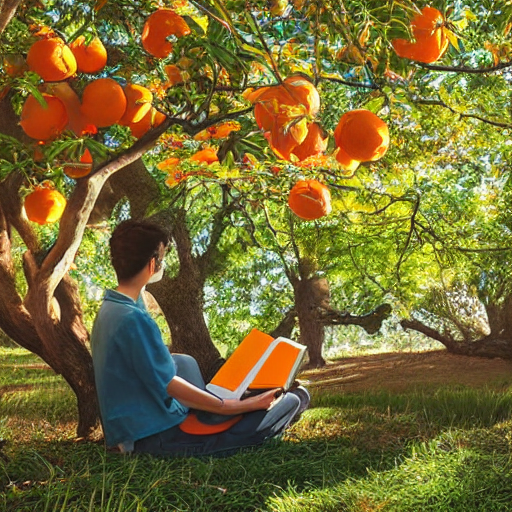

In [43]:
result_image = createImage(created_prompt, SD_CHECKPOINT)
result_image

In [81]:
def ImageToBase64(image) :
    # base64로 직렬화
    _, buffer = cv2.imencode(".jpg", np.array(image))
    base64_encoded = base64.b64encode(buffer)
    base64_string = base64_encoded.decode('utf-8')

    return base64_string

In [82]:
def base64ToImage(image_base64 : str) :
    ## base64 to image
    img_bytes = base64.b64decode(image_base64)
    nparr = np.frombuffer(img_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    return img

In [83]:
client_Gemini = None

def validateImage(image_base64 : str, prompt : str) :
  ''' 생성된 이미지와 프롬프트의 일치율을 분석하는 함수 '''
  global client_Gemini
  if client_Gemini is None :
    client_Gemini = genai.Client(api_key=api_key)

  # base64 이미지데이터를 gemini가 인식하는 데이터형태로 감싸기
  img_bytes = base64.b64decode(image_base64)
  image_for_gemini  = types.Part.from_bytes(
      data = img_bytes,
      mime_type = "image/jpeg"
  )

  valid_prompt = f"""
  제공된 이미지가 프롬프트 '{prompt}'와 얼마나 일치하는지
  점수로 평가해주세요.
    - 일치도 : 00.00 %
    - 평가요소 설명
    - 설명1 (일치도)
    - 설명2 (일치도)
    - ...
  """
  response_msg = ""
  try :
    # gemini에게 평가하기
    response = client_Gemini.models.generate_content(
        model = "gemini-2.5-flash",
        contents = [valid_prompt, image_for_gemini]
    )
    response_msg = response.text.strip()
  except Exception as e:
    # GPT-4o 멀티모달 요청
    response = openai.chat.completions.create(
        model = "gpt-4o",
        messages = [
            {
                "role" : "user",
                "content" : [
                    {"type" : "text", "text" : valid_prompt},
                    {"type" : "image_url",
                      "image_url" : {"url" : "data:image/png;base64," +
                                    image_base64}
                    }
                ]
            }
        ]
    )
    response_msg = response.choices[0].message.content
  return response_msg

In [84]:
valid_result = validateImage(ImageToBase64(result_image), created_prompt)

In [85]:
print(valid_result)

일치도: 60.00%

- 설명1 (일치도): 이미지에서 한 사람이 책을 읽고 앉아 있는 모습은 프롬프트와 일치합니다.
- 설명2 (일치도): 나무 아래에 앉아 있는 점은 유사하지만, 나무가 오렌지나무가 아니라 파란 열매를 맺고 있어 색상이 다릅니다.
- 설명3 (일치도): 햇빛이 나뭇잎 사이로 비치고 있는 점에서 분위기는 비슷하지만, 오렌지 잎이나 열매의 색이 아닌 초록/파란색 계열이라 색상이 크게 다릅니다.
- 설명4 (일치도): 배경의 자연적 색조는 있지만 전반적으로 원하는 따뜻한 색감보다는 차가운 색조입니다.


In [86]:
def extract_score(valid_result : str) :
    match_result = re.search(r"일치도\s*:\s*([\d.]+)",
                             valid_result)

    return float(match_result.group(1))

In [66]:
extract_score(valid_result)

AttributeError: 'NoneType' object has no attribute 'group'

## 상태(State) 정의

In [87]:
class ImageAgentState(TypedDict) :
    user_prompt : Annotated[str, "user input prompt"]
    created_prompt : Annotated[str, 'AI create prompt']
    score : Annotated[float, 'valid image score']
    evaluate_result : Annotated[str, 'evaluate msg']
    current_repeat_num : Annotated[int, "current_repeat_num"]
    max_repeat_num : Annotated[int, "max_repeat_num"]
    checkpoint : Annotated[str, "model checkpoint"]
    image : Annotated[str, "base64 encoded image"]
    threshold : Annotated[float, "threshold"]

## 노드 정의

In [88]:
def set_prompt_node(s:ImageAgentState) -> ImageAgentState:
    num = s['current_repeat_num']
    if s['created_prompt'] == None :
        created_prompt = setPrompt(s['user_prompt'])
    else :
        self_reflection_prompt = f"""
        생성한 이미지에 대한 평가결과 {s['evaluate_result']}를 분석하여
        유사도를 개선할 수 있도록 {s['created_prompt']} 내용을 개선한 프롬프트 생성
        """

        created_prompt = setPrompt(self_reflection_prompt)
        #반복횟수 증가
        num += 1

    return ImageAgentState(created_prompt = created_prompt,
                           current_repeat_num = num)

In [89]:
def create_image_node(s:ImageAgentState) -> ImageAgentState:
    img = createImage(s['created_prompt'], s['checkpoint'])
    img_base64 = ImageToBase64(img)
    return ImageAgentState(image = img_base64)


In [90]:
def validate_image_node(s:ImageAgentState) -> ImageAgentState:
    valid_result = validateImage(s['image'], s['created_prompt'])
    score = extract_score(valid_result)
    return ImageAgentState(score = score,
                           evaluate_result = valid_result)

In [91]:
 # 분기를 위한 router 함수
def imageRouter(s:ImageAgentState) :
  if s['max_repeat_num'] <= s['current_repeat_num'] :
    return 'stop'

  if s['score'] < s['threshold'] :
    return 'repeat'
  else :
    return 'stop'

## 그래프 구축 및 실행

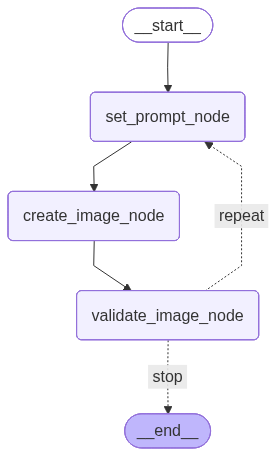

In [92]:
workflow = StateGraph(ImageAgentState) # 그래프 베이스 생성
# 노드 붙이기
workflow.add_node("set_prompt_node", set_prompt_node)
workflow.add_node("create_image_node", create_image_node)
workflow.add_node("validate_image_node", validate_image_node)
# 엣지 붙이기
workflow.add_edge(START, "set_prompt_node")
workflow.add_edge("set_prompt_node", "create_image_node")
workflow.add_edge("create_image_node", "validate_image_node")
workflow.add_conditional_edges(
    'validate_image_node',
    imageRouter,
    {
        'repeat' : "set_prompt_node",
        'stop' : END
    }
)
# 컴파일 및 시각화
app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))


In [93]:
# 실행하기
config = RunnableConfig({'recursion_limit' : 20})
input = ImageAgentState(
    user_prompt = "여름 바닷가에서 공놀이 하는 사람들",
    created_prompt = None,
    current_repeat_num = 0,
    max_repeat_num = 3,
    checkpoint = SD_CHECKPOINT,
    threshold = 75.0
)

for rs in app.stream(input=input, config=config) :
    print(rs)

{'set_prompt_node': {'created_prompt': 'Photorealistic scene of a diverse group of people playing with a colorful beach ball on a sunny summer beach — golden sand, gentle waves lapping the shore, bright blue sky with a few fluffy clouds, casual summer clothing, joyful expressions and dynamic motion with small splashes, warm natural sunlight, vibrant colors, shallow depth of field, high-resolution, wide-angle composition.', 'current_repeat_num': 0}}


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['hour ( approx . 3 5 0 0 – 4 5 0 0 k ) while preserving true - to - life skin tones — no cyan / blue tint on sand , water , or skin and no exaggerated orange / teal or blue / orange color casts . natural , believable shadows and realistic specular highlights on wet sand and skin ; moderate saturation and natural contrast , no oversaturated , neon , or surreal color grading — use subtle , restrained color correction only . background rendered with correct perspective , scale and soft atmospheric depth ( no flattened or unnatural background artifacts ), shallow depth of field with subjects crisp and background softly blurred . high - resolution , wide - angle composition ( approx . 3 5 mm , wide aperture f / 2 . 8 – f / 4 ), photorealistic color grading , fine natural texture detail ( visible skin pores , wet sand grains ), no stylized , painterly , or surreal effects .']


{'set_prompt_node': {'created_prompt': 'Photorealistic scene of a diverse group of people playing with a colorful beach ball on a sunny summer beach — golden sand, gentle waves lapping the shore, bright blue sky with a few fluffy clouds, casual summer clothing, joyful expressions and dynamic motion with small splashes. Warm natural sunlight with strong directional golden-hour lighting; accurate exposure and white balance adjusted for warm golden-hour (approx. 3500–4500K) while preserving true-to-life skin tones — no cyan/blue tint on sand, water, or skin and no exaggerated orange/teal or blue/orange color casts. Natural, believable shadows and realistic specular highlights on wet sand and skin; moderate saturation and natural contrast, no oversaturated, neon, or surreal color grading — use subtle, restrained color correction only. Background rendered with correct perspective, scale and soft atmospheric depth (no flattened or unnatural background artifacts), shallow depth of field with 

  0%|          | 0/50 [00:00<?, ?it/s]

{'create_image_node': {'image': '...'}}


AttributeError: 'NoneType' object has no attribute 'group'

In [94]:
rs

{'create_image_node': {'image': '...'}}

array([[[130, 144, 203],
        [131, 145, 204],
        [132, 146, 205],
        ...,
        [152, 153, 209],
        [151, 152, 210],
        [151, 152, 210]],

       [[130, 144, 203],
        [131, 145, 204],
        [132, 146, 205],
        ...,
        [151, 152, 208],
        [151, 152, 210],
        [151, 152, 210]],

       [[131, 145, 204],
        [132, 146, 205],
        [132, 146, 205],
        ...,
        [151, 152, 208],
        [151, 152, 210],
        [151, 152, 210]],

       ...,

       [[152, 145, 148],
        [155, 150, 152],
        [153, 147, 152],
        ...,
        [143, 132, 140],
        [125, 114, 122],
        [141, 130, 138]],

       [[152, 141, 149],
        [144, 136, 143],
        [136, 127, 137],
        ...,
        [131, 125, 130],
        [121, 114, 119],
        [117, 110, 115]],

       [[132, 121, 131],
        [125, 114, 124],
        [107,  97, 110],
        ...,
        [107, 103, 108],
        [104,  98, 103],
        [119, 113, 118]]], dtype=uint8)
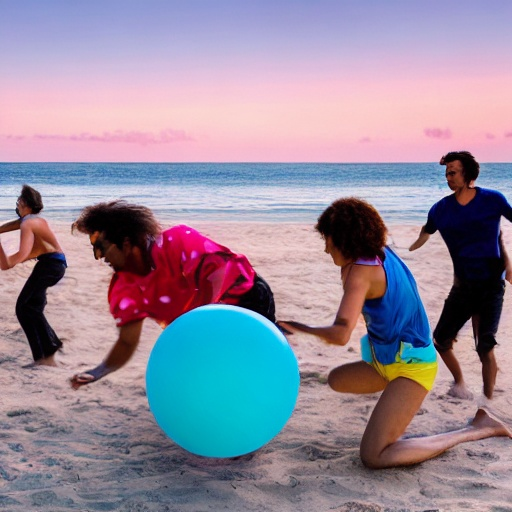

In [95]:
base64ToImage(rs['create_image_node']['image'])